# Closed Loop Simulation With feedforward

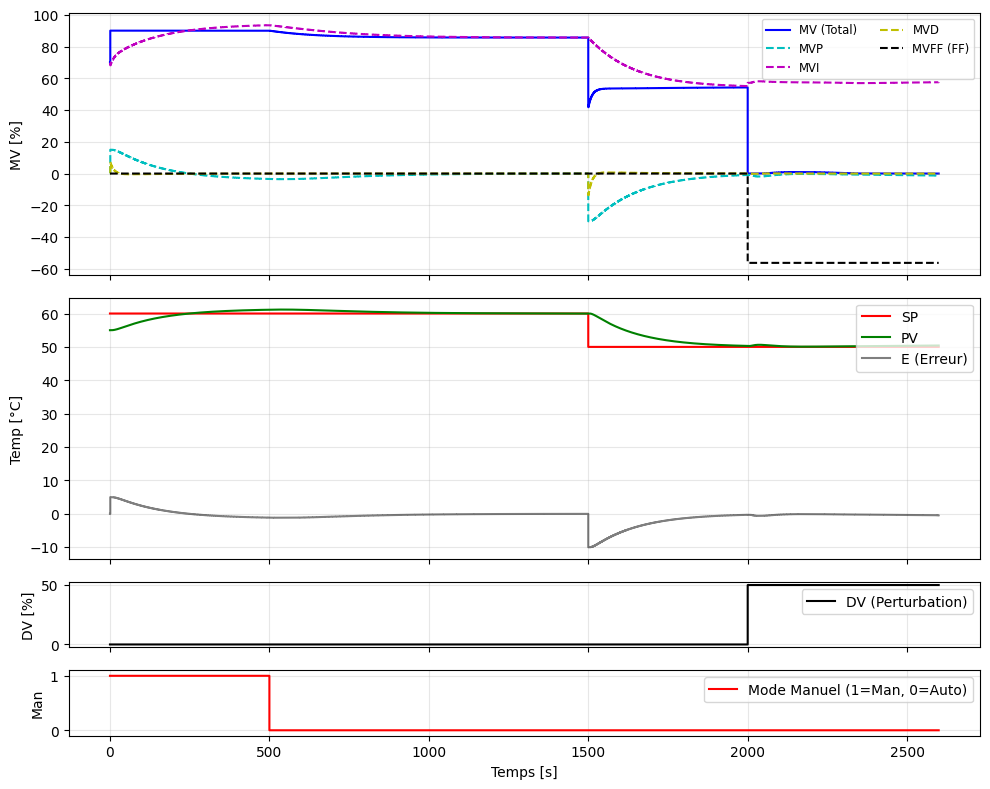

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors

import package_DBR
from package_DBR import myRound, SelectPath_RT, Delay_RT, FO_RT, FOPDT, SOPDT, FOPDT_cost, SOPDT_cost, Process, Bode
import package_LAB
from package_LAB import LL_RT, PID_RT


Ts = 1.0
Tsim = 2600
t = np.arange(0, Tsim, Ts)

# Modèles (issus de tes identifications)
K_p, T1_p, T2_p, theta_p = 0.32, 149.5, 15.0, 4.0   # Procédé (H1 -> T1)
K_d, T1_d, T2_d, theta_d = 0.36, 170.77, 6.12, 5.43  # Perturbation (H2 -> T1)

# Réglages PID
Kc, Ti, Td, alpha = 3.0, 150.0, 5.0, 2
MVMin, MVMax = 0, 100

# Conditions initiales
PV_init = 55
MV_init = 70

# --- Signaux d'entrée ---

# 1. Mode Manuel : Actif de 0 à 500s
Man = np.zeros_like(t, dtype=bool)
Man[t < 500] = True

# 2. Valeur Manuelle : On fixe la commande à 50% pendant la phase manuelle
MVMan = np.ones_like(t) * 90

# 3. Consigne SP
SP = np.ones_like(t) * 60
SP[t >= 1500] = 50

# 4. Perturbation DV
DV = np.zeros_like(t)
DV[t >= 2000] = 50.0

# 5. Feedforward
USE_FF = True 
MVFF = -(K_d / K_p) * DV if USE_FF else np.zeros_like(t)

# ==============================================================================
# BOUCLE DE SIMULATION
# ==============================================================================
# Initialisation des listes avec MV_init / PV_init
MV, MVP, MVI, MVD, E, PV = [MV_init], [0.0], [MV_init], [0.0], [0.0], [PV_init]
PV1_p, PV2_p = [0.0], [0.0]
PV1_d, PV2_d = [0.0], [0.0]

for i in range(1, len(t)):
    # Modèle Procédé
    d_p = int(theta_p/Ts)
    mv_in = MV[i-d_p-1] - MV_init if i > d_p else 0
    PV1_p.append((T1_p/(T1_p+Ts))*PV1_p[-1] + (K_p*Ts/(T1_p+Ts))*mv_in)
    PV2_p.append((T2_p/(T2_p+Ts))*PV2_p[-1] + (Ts/(T2_p+Ts))*PV1_p[-1])
    
    # Modèle Perturbation
    d_d = int(theta_d/Ts)
    dv_in = DV[i-d_d-1] if i > d_d else 0
    PV1_d.append((T1_d/(T1_d+Ts))*PV1_d[-1] + (K_d*Ts/(T1_d+Ts))*dv_in)
    PV2_d.append((T2_d/(T2_d+Ts))*PV2_d[-1] + (Ts/(T2_d+Ts))*PV1_d[-1])
    
    # PV totale
    PV.append(PV_init + PV2_p[-1] + PV2_d[-1])
    
    # PID (Gère le passage Manuel -> Auto à t=500)
    PID_RT(SP[:i+1], PV, Man[:i+1], MVMan[:i+1], MVFF[:i+1], Kc, Ti, Td, alpha, Ts, 
           MVMin, MVMax, MV, MVP, MVI, MVD, E, PVInit=PV_init)

# ==============================================================================
# GRAPHIQUES (4 axes - Style Prof)
# ==============================================================================
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [2, 2, 0.5, 0.5]})

# Graph 1 : Signaux de commande (MV et ses composantes)
ax1.step(t, MV, 'b', label='MV (Total)', where='post', linewidth=1.5)
ax1.step(t, MVP, 'c--', label='MVP', where='post')
ax1.step(t, MVI, 'm--', label='MVI', where='post')
ax1.step(t, MVD, 'y--', label='MVD', where='post')
ax1.step(t, MVFF, 'k--', label='MVFF (FF)', where='post')
ax1.set_ylabel('MV [%]')
ax1.legend(loc='upper right', fontsize='small', ncol=2)
ax1.grid(True, alpha=0.3)

# Graph 2 : Températures (SP, PV) et Erreur
ax2.step(t, SP, 'r', label='SP', where='post')
ax2.plot(t, PV, 'g', label='PV')
ax2.step(t, E, 'k', label='E (Erreur)', where='post', alpha=0.5)
ax2.set_ylabel('Temp [°C]')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# Graph 3 : Perturbation (DV)
ax3.step(t, DV, 'k', label='DV (Perturbation)', where='post')
ax3.set_ylabel('DV [%]')
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)

# Graph 4 : État Manuel vs Auto (Variable Man)
ax4.step(t, Man.astype(int), 'r', label='Mode Manuel (1=Man, 0=Auto)', where='post')
ax4.set_ylabel('Man')
ax4.set_xlabel('Temps [s]')
ax4.set_ylim([-0.1, 1.1])
ax4.legend(loc='upper right')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()